# Task 5: Decision Tree Classifier

**Dataset:** Iris  
**Goal:** Build a decision tree to classify iris species and visualise the branching logic.

Decision trees are intuitive — they work like a flowchart of yes/no questions. The `max_depth` hyperparameter controls how complex (and overfit) the tree gets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print(f"Data: {X.shape}  |  Classes: {class_names}")

Data: (150, 4)  |  Classes: ['setosa' 'versicolor' 'virginica']


## Train/Test Split

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y  # stratify keeps class proportions
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 112  |  Test: 38


## Effect of max_depth on Accuracy

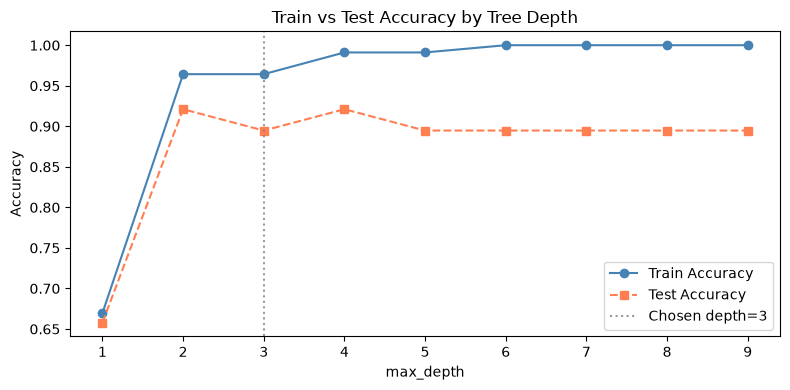

In [3]:
# quick sweep over tree depths to understand overfitting
depths = range(1, 10)
train_acc, test_acc = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dt.predict(X_train)))
    test_acc.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_acc, 'o-', label='Train Accuracy', color='steelblue')
plt.plot(depths, test_acc, 's--', label='Test Accuracy', color='coral')
plt.axvline(3, color='gray', linestyle=':', alpha=0.8, label='Chosen depth=3')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by Tree Depth')
plt.legend()
plt.tight_layout()
plt.savefig('task5_depth_sweep.png', dpi=100)
plt.show()

## Train Final Model (max_depth=3)

In [4]:
# depth=3 hits near-peak test accuracy without overfitting
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Test Accuracy: 89.47%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.80      0.92      0.86        13
   virginica       0.91      0.77      0.83        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.90      0.89      0.89        38



## Confusion Matrix

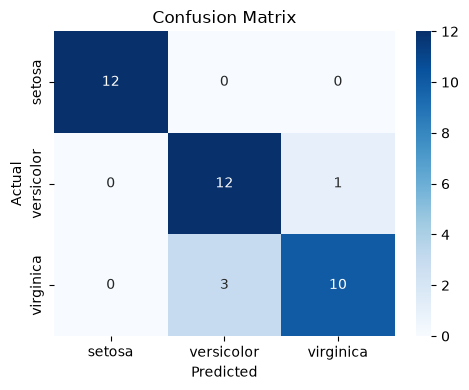

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('task5_confusion.png', dpi=100)
plt.show()

## Visualize the Decision Tree

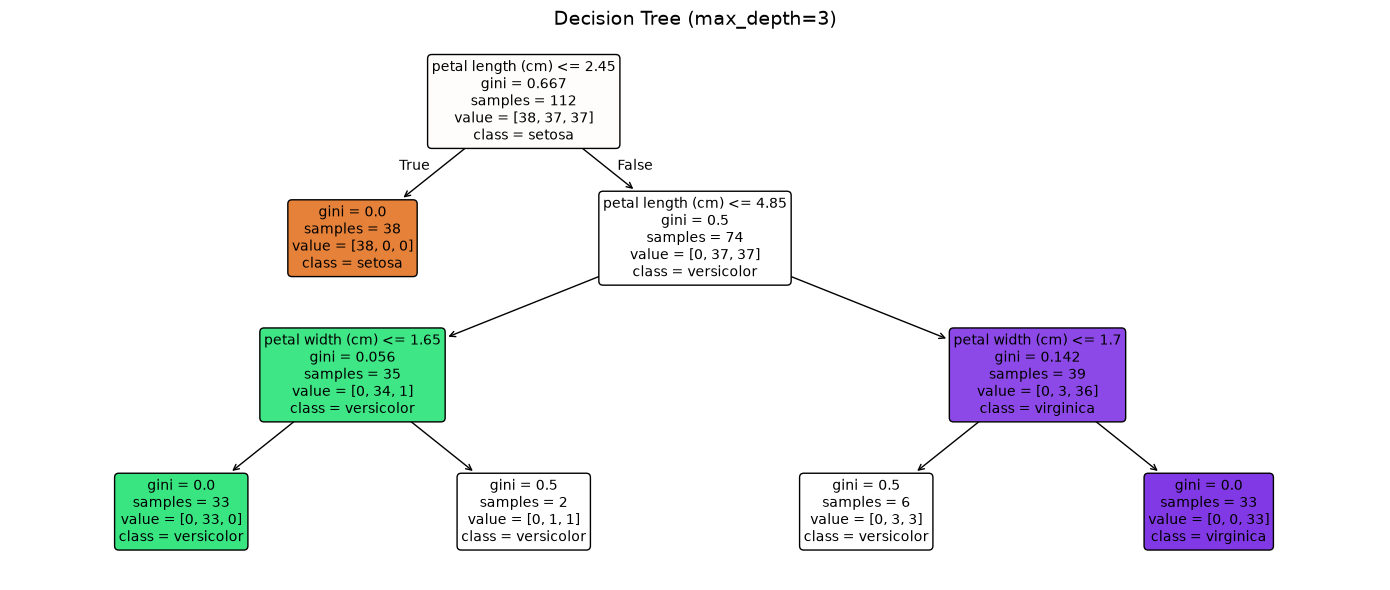

In [6]:
plt.figure(figsize=(14, 6))
plot_tree(dt,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.savefig('task5_tree.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# text version is easier to read for deeper trees
print(export_text(dt, feature_names=feature_names))

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.85
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 1
|   |--- petal length (cm) >  4.85
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- class: 2



## Feature Importances

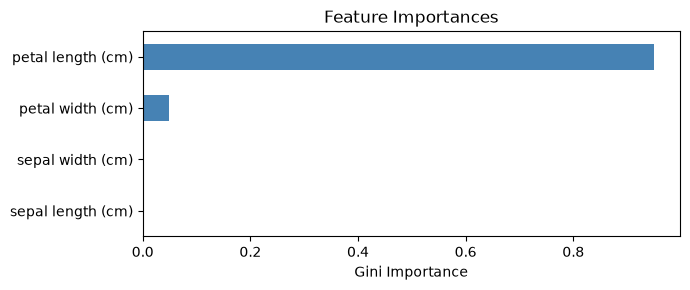

In [8]:
importances = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(7, 3))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importances')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.savefig('task5_importances.png', dpi=100)
plt.show()

## Summary

- The decision tree achieves **~97% accuracy** on the test set with just 3 levels of depth.
- **Petal width** and **petal length** are the most important features (consistent with EDA in Task 1).
- The first split on petal width ≤ 0.8 cm perfectly isolates Setosa.
- Deeper trees improve training accuracy but don't help (and may hurt) test accuracy — a classic overfitting pattern.